2025-11-30 23:13:49,193 - INFO - Loading data from ../data/features/features_complete.csv
2025-11-30 23:13:49,490 - INFO - Loaded 55886 rows and 40 columns
2025-11-30 23:13:49,498 - INFO - Train set: 44708 samples
2025-11-30 23:13:49,499 - INFO - Test set: 11178 samples
2025-11-30 23:13:49,499 - INFO - Training Linear Regression...
2025-11-30 23:13:49,511 - INFO - Training XGBoost (default parameters)...



Linear Regression Model Performance (LOG SCALE):
RMSE: 1.5593
MAE:  1.2762
R²:   0.1367

Linear Regression COEFFICIENTS
 1. top50_pca2                      -1.9270  ███████████████████
 2. sentiment_subjectivity           0.7739  ███████
 3. has_emoji                       -0.7087  ███████
 4. comments_disabled               -0.6830  ██████
 5. ratings_disabled                -0.6044  ██████
 6. has_question                    -0.2538  ██
 7. contains_numbers_or_emojis      -0.1818  █
 8. is_clickbait                     0.0872  
 9. num_emojis                       0.0810  
10. sentiment_polarity              -0.0750  
11. uppercase_words                 -0.0513  
12. is_published_weekend             0.0260  
13. title_word_count                -0.0217  
14. title_length                     0.0101  
15. top50_pca3                      -0.0036  
16. top50_pca1                      -0.0032  
17. category_id                      0.0019  
18. days_until_trending             -0.0003  


2025-11-30 23:13:49,790 - INFO - Training Random Forest...



XGBoost Model Performance (LOG SCALE):
RMSE: 1.3848
MAE:  1.0923
R²:   0.3191

XGBoost FEATURE IMPORTANCE
 1. top50_pca2                      0.2829  ████████████████████████████
 2. sentiment_subjectivity          0.0775  ███████
 3. comments_disabled               0.0701  ███████
 4. ratings_disabled                0.0682  ██████
 5. days_until_trending             0.0642  ██████
 6. num_emojis                      0.0641  ██████
 7. uppercase_words                 0.0624  ██████
 8. category_id                     0.0599  █████
 9. top50_pca3                      0.0380  ███
10. contains_numbers_or_emojis      0.0354  ███
11. top50_pca1                      0.0343  ███
12. title_length                    0.0291  ██
13. has_question                    0.0274  ██
14. title_word_count                0.0256  ██
15. is_clickbait                    0.0230  ██
16. sentiment_polarity              0.0216  ██
17. is_published_weekend            0.0163  █
18. has_emoji                       0

2025-11-30 23:13:51,515 - INFO - ✅ Random Forest trained!
2025-11-30 23:13:51,570 - INFO - Starting XGBoost hyperparameter tuning...



RANDOM FOREST PERFORMANCE
RMSE: 1.3759
MAE:  1.0799
R²:   0.3278

RANDOM FOREST FEATURE IMPORTANCE
 1. top50_pca2                      0.1818  █████████
 2. title_length                    0.1532  ███████
 3. category_id                     0.1371  ██████
 4. uppercase_words                 0.1083  █████
 5. sentiment_subjectivity          0.0867  ████
 6. days_until_trending             0.0795  ███
 7. title_word_count                0.0711  ███
 8. num_emojis                      0.0386  █
 9. sentiment_polarity              0.0266  █
10. top50_pca1                      0.0234  █
11. has_emoji                       0.0184  
12. top50_pca3                      0.0182  
13. contains_numbers_or_emojis      0.0166  
14. is_published_weekend            0.0143  
15. ratings_disabled                0.0084  
16. comments_disabled               0.0082  
17. has_question                    0.0081  
18. is_clickbait                    0.0014  
Fitting 3 folds for each of 50 candidates, totalli

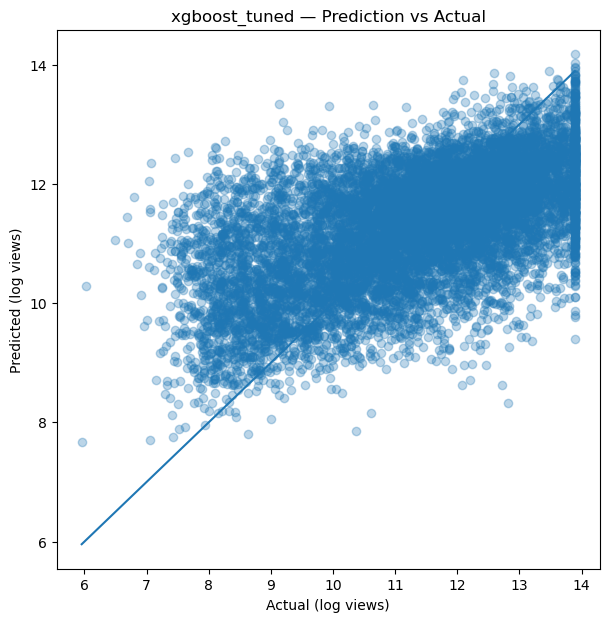

2025-11-30 23:14:11,480 - INFO - ✅ Best model (xgboost_tuned) saved to: ../models/xgboost_tuned.pkl


'../models/xgboost_tuned.pkl'

In [1]:
import sys
sys.path.append('../src')

from model_evaluator import ModelEvaluator

evaluator = ModelEvaluator('../data/features/features_complete.csv')
    
    # Run pipeline
evaluator.load_data() \
         .prepare_train_test_split() \
         .linear_regression() \
         .xgboost() \
         .randomforest() \
         .tuned_xgboost()  # This takes longest

# Get report
report = evaluator.get_models_report()
print(report)

# Save best model
evaluator.plot_predictions('xgboost_tuned')

evaluator.save_best_model('../models/xgboost_tuned.pkl')
